# Supervised Regression mit `scikit-learn`

## Schritt 1: Werkzeuge laden

Ladet folgende Werkzeuge in eurem Python-Kernel:

* `read_csv` aus `pandas`
* `train_test_split` aus dem `model_selection`-Modul in `scikit-learn`
* `DecisionTreeRegressor` aus dem `tree`-Modul in `scikit-learn`
* `LinearRegression` aus dem `linear_model`-Modul in `scikit-learn`
* `PolynomialFeatures` aus dem `preprocessing`-Modul in `scikit-learn`
* `r2_score` aus dem `metrics`-Modul in `scikit-learn`
* `mean_absolute_error` aus dem `metrics`-Modul in `scikit-learn`
* `root_mean_squared_error` aus dem `metrics`-Modul in `scikit-learn`

In [69]:
# Euer Code
# Anzahl casual entleihungen | cnt = Gesamtausleihung

# Aufgabe: Anzahl ausgeliehenen Fahrräder schätzen
# Wenns morgen regnet, wie viel ausleihungen haben wir zu erwarten?
# Target casual oder registered oder beides? Ctn sein vorschlag, aber dann die andern nicht als feature verwenden


In [70]:
# Daten einlesen
from pandas import read_csv

# Daten in Trainings- und Test-Set aufteilen
from sklearn.model_selection import train_test_split

# Werkzeuge zum Explorieren
from seaborn import pairplot, heatmap
from matplotlib import pyplot as plt

# Regressions-Modelle
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Feature-Erweiterung für die Polynomialregression
from sklearn.preprocessing import PolynomialFeatures

# Bewertungs-Metriken für Regression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error




## Schritt 2: Daten Laden

Ladet den `bikesharing.csv`-Datensatz in `pandas`. Bereinigt den Datensatz beim Laden, falls nötig. 

In [71]:
# Laden: ";" als Trennzeichen, Titelzeile (Zeile 0) überspringen, nur die 16 echten Spalten laden
data = read_csv("../data/bikesharing.csv", sep=";", skiprows=[0], usecols=range(16), nrows=310)

# Zeilen mit fehlenden Werten entfernen
data = data.dropna()

## Schritt 3: Daten explorieren

Schaut euch die Daten an. Verwendet dazu Statistiken, Plots und die Standard-Methoden, die `pandas` für euch bereithält.

In [72]:
# Euer Code
# Pair plot, richtige Maßnahme ergreifen. Probleme behenben bevor weitermachen

In [73]:
# Erster Blick auf die Daten
data.head()

,id,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,day,month,year
0,0.0,spring,no,Sat,no,cloudy,0.344167,0.363625,0.805833,0.160446,331.0,654.0,985.0,1.0,1.0,2011.0
2,2.0,spring,no,Mon,no,clear sky,0.196364,0.189405,0.437273,0.248309,120.0,1229.0,1349.0,3.0,1.0,2011.0
3,3.0,spring,no,Tue,no,clear sky,0.200000,0.212122,0.590435,0.160296,108.0,1454.0,1562.0,4.0,1.0,2011.0
5,5.0,spring,no,Thu,no,clear sky,0.204348,0.233209,0.518261,0.089565,88.0,1518.0,1606.0,6.0,1.0,2011.0
6,6.0,spring,no,Fri,no,cloudy,0.196522,0.208839,0.498696,0.168726,148.0,1362.0,1510.0,7.0,1.0,2011.0


In [74]:
# Überblick: Datentypen, Anzahl Einträge und statistische Kennzahlen
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 298 entries, 0 to 307
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          298 non-null    float64
 1   season      298 non-null    object 
 2   holiday     298 non-null    object 
 3   weekday     298 non-null    object 
 4   workingday  298 non-null    object 
 5   weathersit  298 non-null    object 
 6   temp        298 non-null    float64
 7   atemp       298 non-null    float64
 8   hum         298 non-null    float64
 9   windspeed   298 non-null    float64
 10  casual      298 non-null    float64
 11  registered  298 non-null    float64
 12  cnt         298 non-null    float64
 13  day         298 non-null    float64
 14  month       298 non-null    float64
 15  year        298 non-null    float64
dtypes: float64(11), object(5)
memory usage: 39.6+ KB


,id,temp,atemp,hum,windspeed,casual,registered,cnt,day,month,year
count,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.0
mean,157.392617,0.517797,0.493344,0.643582,0.192427,744.432886,2799.191275,3543.624161,15.573826,5.724832,2011.0
std,87.694240,0.192519,0.171937,0.147982,0.073918,575.903153,1061.055462,1402.789246,8.886277,2.880000,0.0
min,0.000000,0.059130,0.079070,0.000000,0.022392,9.000000,472.000000,506.000000,1.000000,1.000000,2011.0
25%,82.250000,0.344865,0.350623,0.538854,0.137368,289.250000,1739.250000,2123.750000,8.000000,3.000000,2011.0
50%,158.500000,0.542119,0.527073,0.649991,0.185329,673.000000,3107.000000,4038.000000,16.000000,6.000000,2011.0
75%,232.750000,0.681458,0.637007,0.741997,0.233149,897.000000,3720.750000,4685.000000,23.000000,8.000000,2011.0
max,307.000000,0.849167,0.840896,0.972500,0.422275,3065.000000,4614.000000,6043.000000,31.000000,11.000000,2011.0


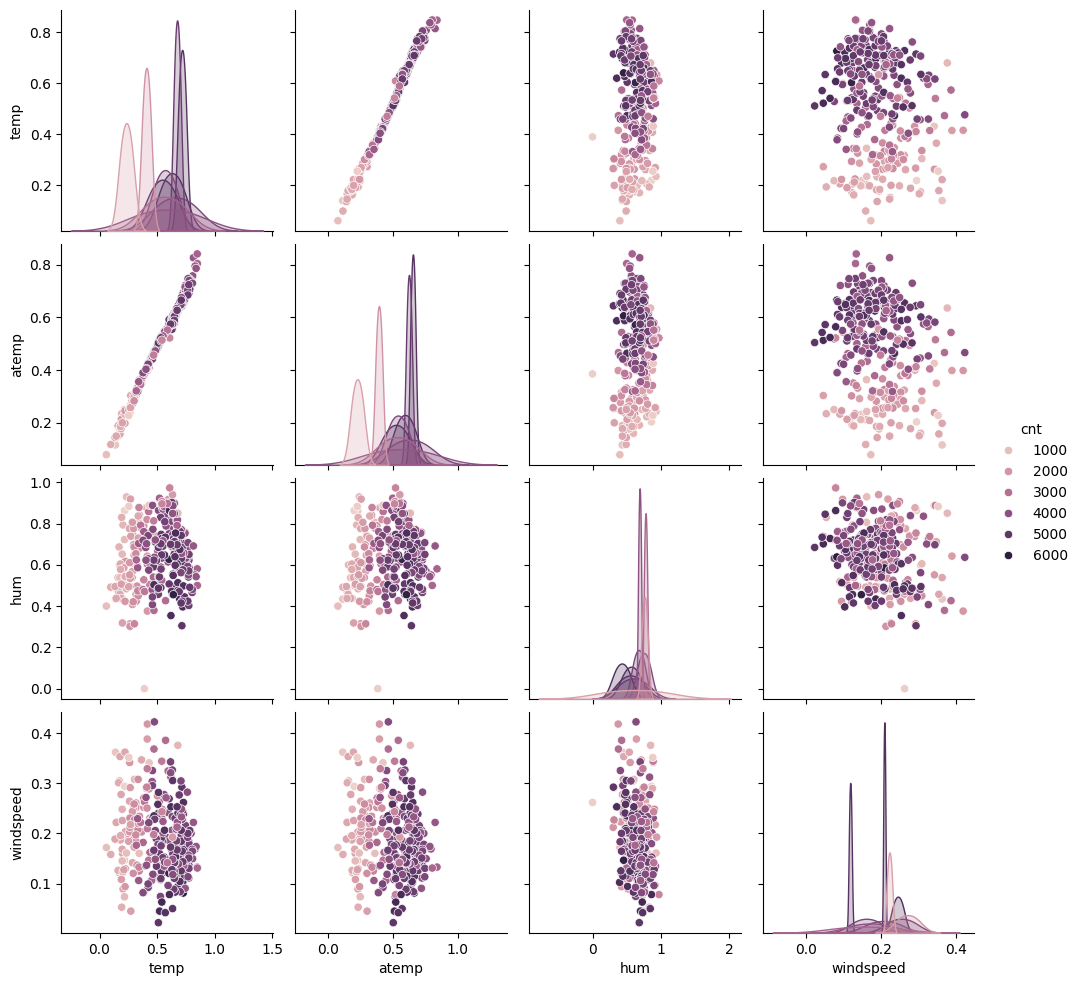

In [75]:
# Pairplot von allen Features, farblich nach der Zielvariable "cnt" unterscheiden
pairplot(data[['temp', 'atemp', 'hum', 'windspeed', 'cnt']], hue='cnt')

Text(0.5, 1.0, 'Häufigkeit der Wetterlagen')

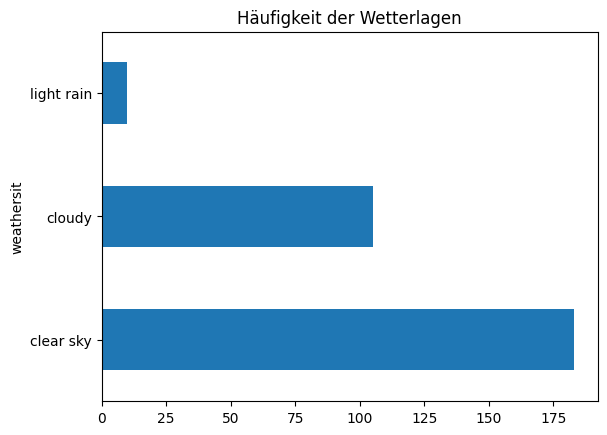

In [76]:
# Häufigkeit der Wetterlagen ansehen (relevant für die Frage "wenn es morgen regnet")
data["weathersit"].value_counts().plot(kind="barh")
plt.title("Häufigkeit der Wetterlagen")

Text(0.5, 1.0, 'Häufigkeit der Jahreszeiten')

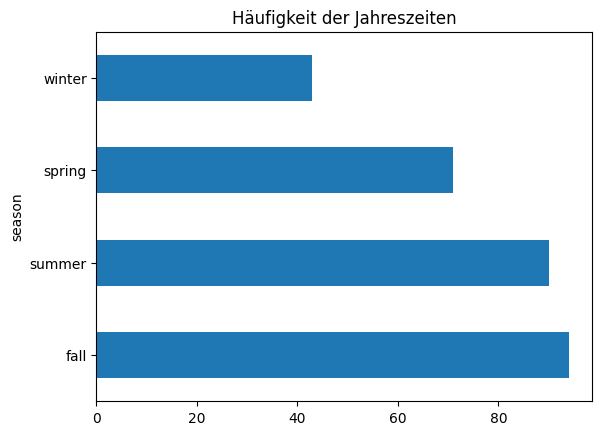

In [77]:
# Häufigkeit der Jahreszeiten ansehen (Saisonalität ist für Fahrrad-Ausleihen relevant)
data["season"].value_counts().plot(kind="barh")
plt.title("Häufigkeit der Jahreszeiten")

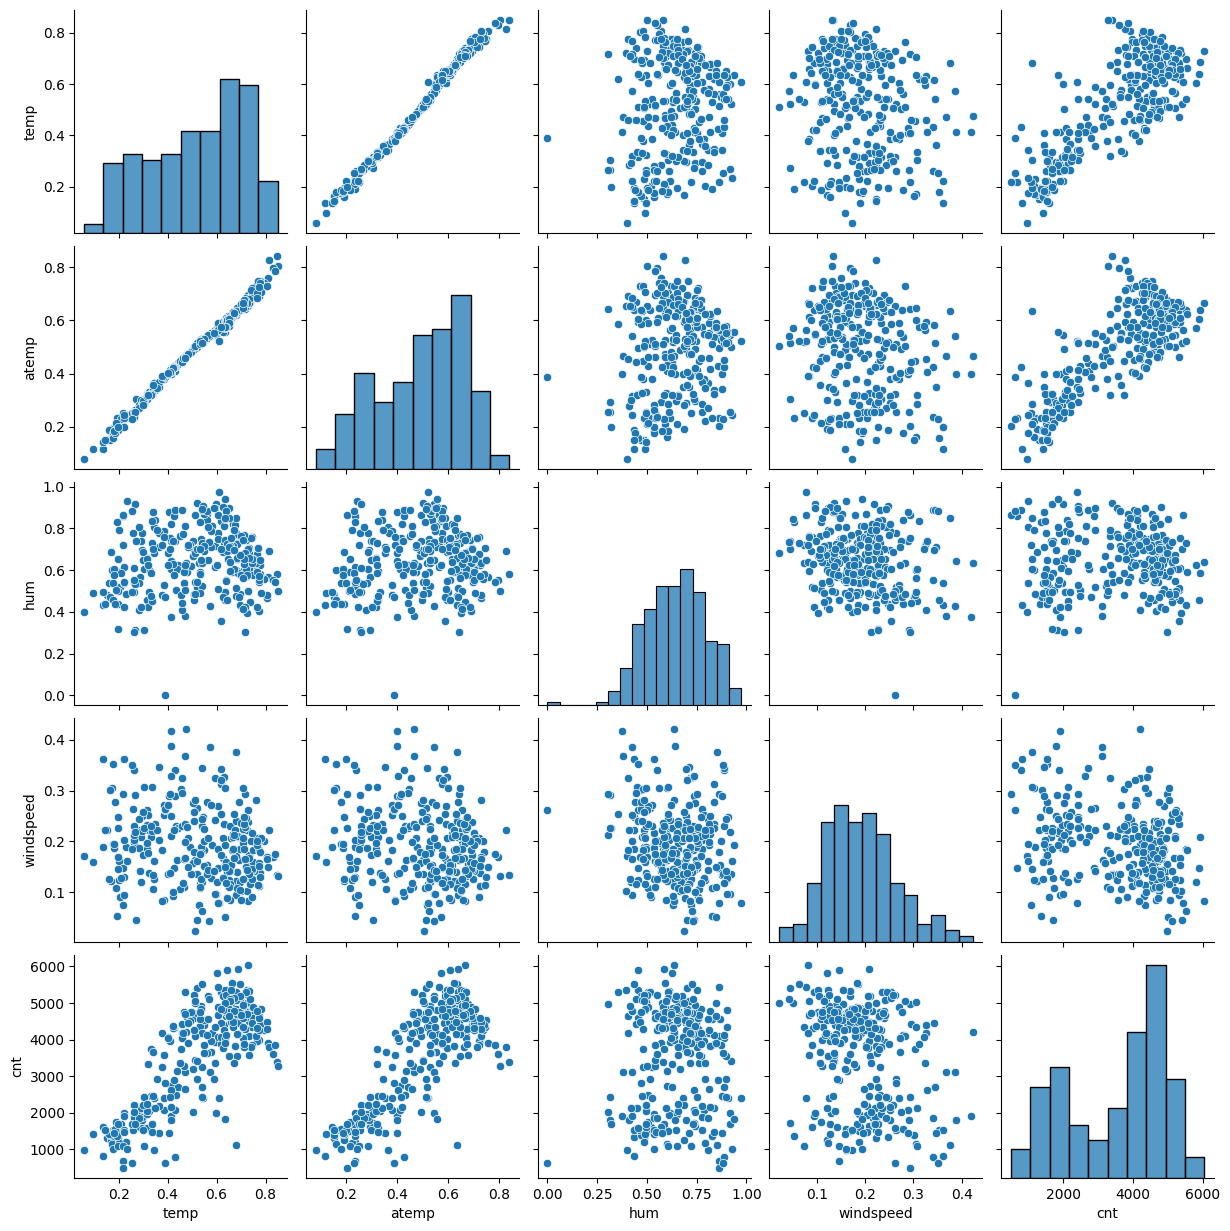

In [78]:
# Pairplot: Zusammenhänge zwischen den Wetter-Features und dem Target cnt
pairplot(data[["temp", "atemp", "hum", "windspeed", "cnt"]])

<Axes: >

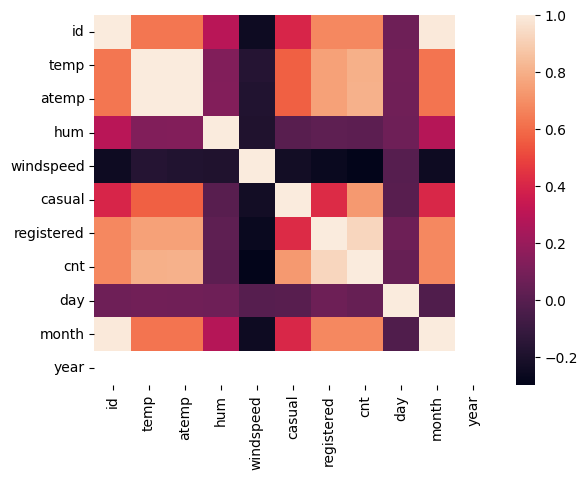

In [79]:
# Korrelationsmatrix aller numerischen Spalten
# Beobachtungen (in Schritt 4 berücksichtigen):
#  - temp & atemp fast identisch -> redundant
#  - casual + registered = cnt -> NICHT als Feature verwenden (Leakage)
#  - year ist konstant (nur 2011) -> bringt nichts
heatmap(data.select_dtypes(include="number").corr())

## Schritt 4: Daten vorbereiten

Bereitet die Daten so vor, dass ihr sie anschließend zum Machine Learning verwenden könnt.

In [80]:
# Euer Code
# montag pipeline verwenden, schauen ob sie passt. Benennung sauber halten
# Daten eliminieren

In [81]:
# Features auswählen: Wetter + Kalender-Kategorien
X = data[["season", "holiday", "weekday", "workingday", "weathersit", "temp", "hum", "windspeed"]]

# Target: Gesamtausleihungen
y = data["cnt"]

In [82]:
# In Trainings- und Test-Set aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [83]:
# Spalten automatisch nach Typ trennen
num_selector = make_column_selector(dtype_include="number")
cat_selector = make_column_selector(dtype_exclude="number")

# Numerisch: fehlende Werte auffüllen + skalieren
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
])

# Kategorial: fehlende Werte auffüllen + One-Hot-codieren
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, num_selector),
    ("cat", categorical_transformer, cat_selector),
])

In [84]:
# Pipeline nur auf den Trainingsdaten fitten, dann beide Sets transformieren
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Trainings-Daten vorbereitet:", X_train_prep.shape)
print("Test-Daten vorbereitet:", X_test_prep.shape)

Trainings-Daten vorbereitet: (238, 20)
Test-Daten vorbereitet: (60, 20)


## Schritt 5: Machine Learning

Verwendet den `DecisionTreeRegressor` und die `LinearRegression` um zwei Regressionsmodelle zu entwickeln. Verwendet diese Modelle anschließend um für eure Daten passende Vorhersagen zu erstellen. Nutzt diese Vorhersagen anschließend, um die Qualität eurer Modelle zu überprüfen. Verwendet dazu `r2_score`, `mean_absolute_error` und `root_mean_squared_error`.

In [85]:
# Decision Tree und Linear regression machen. (Hypoparameter bei Decisiontree)

In [86]:
# Modell 1: Decision Tree (mit Hyperparametern, wie in 03)
tree_regressor = DecisionTreeRegressor(max_depth=5, min_samples_split=10, min_samples_leaf=3)
tree_regressor.fit(X_train_prep, y_train)

# Vorhersagen auf den Testdaten
y_pred_tree = tree_regressor.predict(X_test_prep)

# Qualität bewerten
print("Decision Tree")
print("R2  ", r2_score(y_test, y_pred_tree))
print("MAE ", mean_absolute_error(y_test, y_pred_tree))
print("RMSE", root_mean_squared_error(y_test, y_pred_tree))

Decision Tree
R2   0.6107771499484669
MAE  599.8943741209564
RMSE 794.0640037735648


In [87]:
# Modell 2: Lineare Regression
linear_regressor = LinearRegression()
linear_regressor.fit(X_train_prep, y_train)

# Vorhersagen auf den Testdaten
y_pred_linear = linear_regressor.predict(X_test_prep)

# Qualität bewerten
print("Lineare Regression")
print("R2  ", r2_score(y_test, y_pred_linear))
print("MAE ", mean_absolute_error(y_test, y_pred_linear))
print("RMSE", root_mean_squared_error(y_test, y_pred_linear))

Lineare Regression
R2   0.7871118432653453
MAE  474.91497886685113
RMSE 587.2622650343535


In [88]:
# Overfitting-Check: Vorhersage auf den Trainingsdaten mit dem Test vergleichen
# (liegen Trainings- und Test-R2 nah beieinander, gibt es kein Overfitting)
print("Decision Tree      R2 Training:", r2_score(y_train, tree_regressor.predict(X_train_prep)))
print("Decision Tree      R2 Test:    ", r2_score(y_test, y_pred_tree))
print("Lineare Regression R2 Training:", r2_score(y_train, linear_regressor.predict(X_train_prep)))
print("Lineare Regression R2 Test:    ", r2_score(y_test, y_pred_linear))

Decision Tree      R2 Training: 0.8883071642171172
Decision Tree      R2 Test:     0.6107771499484669
Lineare Regression R2 Training: 0.8078355283707165
Lineare Regression R2 Test:     0.7871118432653453


In [89]:
# Die echten Testwerte (zum Vergleich mit y_pred_tree / y_pred_linear)
y_test.values.ravel()

array([4575., 4714., 1263., 3805., 4195., 4630., 4058., 2471.,  683.,
       4563., 4274., 1842., 4381., 4708., 4839., 4844., 4790., 3855.,
       4758., 4713., 4991., 1538., 2134., 3744., 4475., 4687., 3872.,
       5423., 1977., 5312., 4040., 1000., 4660., 5046., 1985., 5180.,
       5305., 4507., 3351., 5119., 5130., 4966., 3846., 2808., 3117.,
       3820., 3840., 5895., 4835., 4338., 1406., 3907., 5117., 1416.,
       3544., 4352., 2416., 3409., 5020., 3267.])

## Extra-Schritt: Polynomialregression

Erstellt ein drittes Modell und verwendet dabei die Klasse `PolynomialFeatures` um die `LinearRegression` auf ein höheres Polynomiallevel zu heben. Verwendet Gemini/ChatGPT/Copilot/... um euch dabei beraten zu lassen, wie ihr so etwas umsetzen könnt. Vergleicht dieses Modell anschließend mit eurer originalen linearen Regression.

In [90]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_prep)
X_test_poly = poly.transform(X_test_prep)

poly_regressor = LinearRegression()
poly_regressor.fit(X_train_poly, y_train)
y_pred_poly = poly_regressor.predict(X_test_poly)

print("Polynomialregression (Grad 2)")
print("R2  ", r2_score(y_test, y_pred_poly))
print("MAE ", mean_absolute_error(y_test, y_pred_poly))
print("RMSE", root_mean_squared_error(y_test, y_pred_poly))

Polynomialregression (Grad 2)
R2   0.7250369164833861
MAE  491.9497382812407
RMSE 667.4112757973647


In [91]:
# Vergleich: normale lineare Regression vs. Polynomialregression
# Die vielen Polynomial-Features (20 -> 231) führen zu Overfitting:
# Train-R2 hoch, Test-R2 schlechter als bei der normalen Linearen.
print("Linear normal       R2 Test: ", r2_score(y_test, y_pred_linear))
print("Polynomial (Grad 2) R2 Test: ", r2_score(y_test, y_pred_poly))
print("Polynomial (Grad 2) R2 Train:", r2_score(y_train, poly_regressor.predict(X_train_poly)))

Linear normal       R2 Test:  0.7871118432653453
Polynomial (Grad 2) R2 Test:  0.7250369164833861
Polynomial (Grad 2) R2 Train: 0.9476485775200189
